# **MOUNT GOOGLE DRIVE(For dataset access)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **EXTRACT DATASET**

In [ ]:
!unzip -q "/content/drive/MyDrive/diabetic-retinopathy-v1.zip" -d /content/


# **VERIFY DATASET PATH AND FILES**

In [ ]:
import os

DATASET_PATH = "/content/diabetic-retinopathy-v1/data/raw/ddb1_v02_01/images"

print("Files in images folder:", os.listdir(DATASET_PATH)[:10])


Files in images folder: ['diaretdb1_image063.png', 'diaretdb1_image028.png', 'diaretdb1_image020.png', 'diaretdb1_image030.png', 'diaretdb1_image070.png', 'diaretdb1_image069.png', 'diaretdb1_image018.png', 'diaretdb1_image058.png', 'diaretdb1_image003.png', 'diaretdb1_image013.png']


# **DATA PREPROCESSING AND SPLITTING**

Dataset shape: (89, 128, 128, 3)
Train shape: (71, 128, 128, 3)
Test shape: (18, 128, 128, 3)


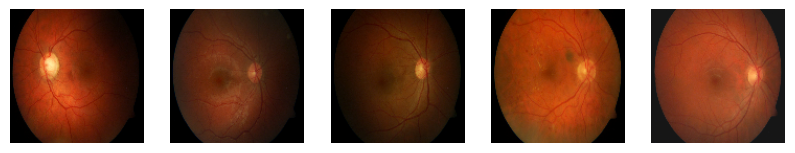

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATASET_PATH = "/content/diabetic-retinopathy-v1/data/raw/ddb1_v02_01/images"

IMG_SIZE = 128
images = []


for filename in os.listdir(DATASET_PATH):
    if filename.endswith(".png"):
        img_path = os.path.join(DATASET_PATH, filename)
        img = cv2.imread(img_path)                # Read image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR->RGB
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # Resize
        img = img.astype("float32") / 255.0        # Normalize [0,1]
        images.append(img)

# Convert to numpy array
images = np.array(images)
print("Dataset shape:", images.shape)  # (89, 128, 128, 3)

# Train-test split (80% train, 20% test)
train, test = train_test_split(images, test_size=0.2, random_state=42)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Show sample images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train[i])
    plt.axis("off")
plt.show()


# **BUILDING THE VARIATIONAL AUTOENCODER(VAE)MODEL**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

LATENT_DIM = 64  # size of latent space

# Encoder
encoder_inputs = layers.Input(shape=(128, 128, 3))
x = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

# Reparameterization trick
def sampling(args):
    z_mean, z_log_var = args
    eps = K.random_normal(shape=K.shape(z_mean), mean=0., stddev=1.0)
    return z_mean + K.exp(0.5 * z_log_var) * eps

z = layers.Lambda(sampling, output_shape=(LATENT_DIM,), name="z")([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

#  Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(32 * 32 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((32, 32, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# VAE (Custom Model)
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)


            reconstruction_loss = tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
            )

            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
            )

            total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction


# Compile
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 64), (None,    │     8,424,640 │
│                                 │ 64), (None, 64))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │     4,316,099 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,740,739 (48.60 MB)

 Trainable params: 12,740,739 (48.60 MB)

 Non-trainable params: 0 (0.00 B)

# **TRAINING THE VARIATIONAL AUTOENCODER(20 Epochs, Batch Size = 32)**

In [ ]:
EPOCHS = 20
BATCH_SIZE = 32

history = vae.fit(train, epochs=EPOCHS, batch_size=BATCH_SIZE)


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 768ms/step - kl_loss: 2.5228 - loss: 11330.8389 - reconstruction_loss: 11336.0850
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 962ms/step - kl_loss: 1.3210 - loss: 11155.0537 - reconstruction_loss: 11176.9971
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - kl_loss: 63.8826 - loss: 10345.3535 - reconstruction_loss: 10395.4785
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 722ms/step - kl_loss: 310.9209 - loss: 8361.2090 - reconstruction_loss: 8059.3906
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 730ms/step - kl_loss: 125.5402 - loss: 7083.6797 - reconstruction_loss: 7033.4683
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - kl_loss: 65.0058 - loss: 6701.4980 - reconstruction_loss: 6596.6709
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - kl_loss: 49.5459 - loss: 6615.6060 - reconstruction_loss: 6583.2383
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 868ms/step - kl_loss: 29.9562 - loss: 6349.4678 - reconstruction_loss: 6320.8076
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 729m

# **COMPARING ORIGINAL Vs RECONSTRUCTED IMAGES**


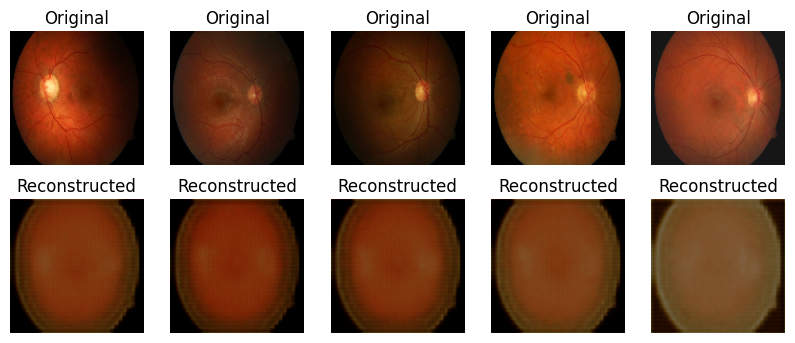

In [ ]:
import matplotlib.pyplot as plt

# Take a batch from your dataset
test_batch = train[:5]   # 5 sample images
reconstructions = vae(test_batch)

plt.figure(figsize=(10, 4))
for i in range(5):
    # Original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(test_batch[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructions[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()

# **GENERATED NEW SYNTHETIC RETINA IMAGES**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


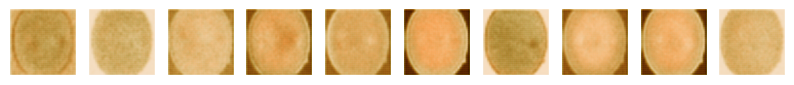

In [ ]:
n_generate = 10  # Number of images to generate
random_latent_vectors = tf.random.normal(shape=(n_generate, LATENT_DIM))
generated_images = vae.decoder.predict(random_latent_vectors)

# Normalize generated images to [0,1]
generated_images = (generated_images - generated_images.min()) / (generated_images.max() - generated_images.min())

# Plot generated images
plt.figure(figsize=(10, 2))
for i in range(n_generate):
    ax = plt.subplot(1, n_generate, i + 1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.show()

# **RECONSTRUCTION ERROR ANALYSIS(MSE & MAE HISTOGRAMS)**


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step


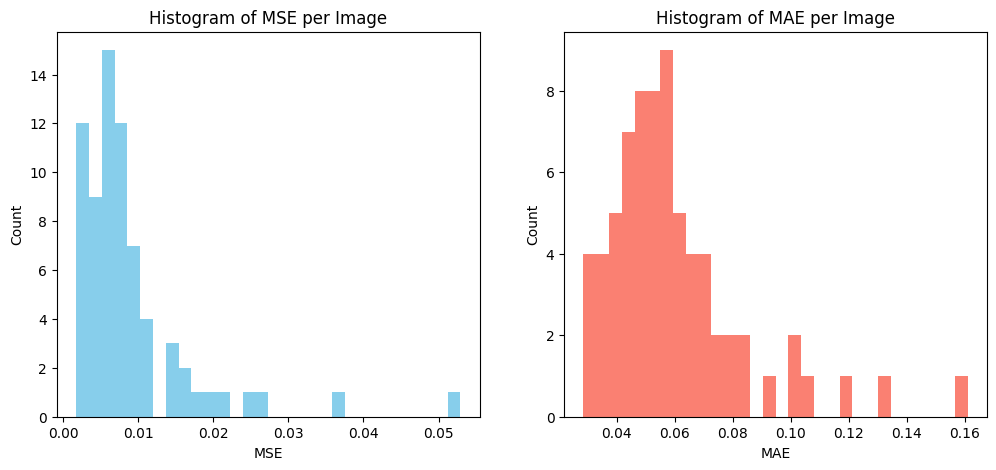

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Get reconstructions
reconstructed = vae.predict(train, batch_size=32)

# Compute errors per image
mse_errors = []
mae_errors = []

for i in range(len(train)):
    orig = train[i].flatten()
    recon = reconstructed[i].flatten()
    mse_errors.append(mean_squared_error(orig, recon))
    mae_errors.append(mean_absolute_error(orig, recon))

mse_errors = np.array(mse_errors)
mae_errors = np.array(mae_errors)

# Show histogram of errors
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(mse_errors, bins=30, color="skyblue")
plt.title("Histogram of MSE per Image")
plt.xlabel("MSE")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(mae_errors, bins=30, color="salmon")
plt.title("Histogram of MAE per Image")
plt.xlabel("MAE")
plt.ylabel("Count")

plt.show()


# **DISTRIBUTION OF RECONSTRUCTION ERRORS WITH THRESHOLD FOR ANOMALY DETECTION**

Test images shape: (20, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
Reconstructed shape: (20, 128, 128, 3)
Reconstruction errors: [0.01475026 0.00753708 0.00857501 0.01214015 0.01974735 0.00916352
 0.0108568  0.00589523 0.00633692 0.00306706 0.01488256 0.00599902
 0.00755259 0.05363926 0.00644128 0.00678239 0.00728935 0.02251098
 0.00980259 0.02461962]
Threshold used: 0.008869264
Predicted labels: [1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 0 0 1 1 1]


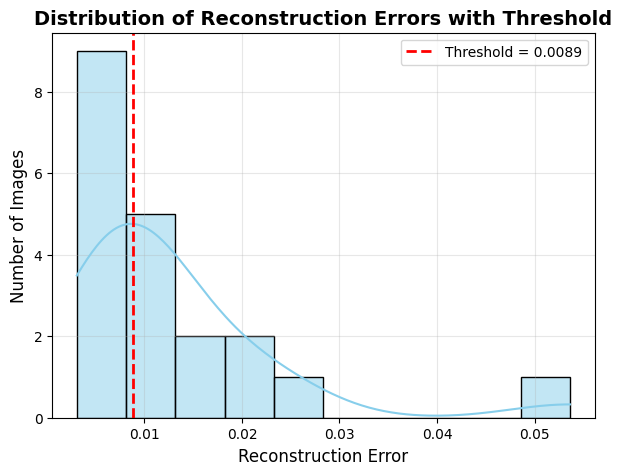

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Taking test images
test_images = train[:20]   # sample 20 images
print("Test images shape:", test_images.shape)

# Reconstruct
reconstructed_images = vae.predict(test_images)
print("Reconstructed shape:", reconstructed_images.shape)

errors = np.mean((test_images - reconstructed_images) ** 2, axis=(1,2,3))
print("Reconstruction errors:", errors)

best_thr = np.median(errors)
y_pred = (errors > best_thr).astype(int)
print("Threshold used:", best_thr)
print("Predicted labels:", y_pred)

plt.figure(figsize=(7,5))
sns.histplot(errors, bins=10, kde=True, color="skyblue", edgecolor="black")
plt.axvline(best_thr, color="red", linestyle="--", linewidth=2,
            label=f"Threshold = {best_thr:.4f}")
plt.xlabel("Reconstruction Error", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Reconstruction Errors with Threshold", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **SELECTING TEST SAMPLES**

In [ ]:
test_batch = next(iter(train))
test_images = test    # taking 20 images as test samples


# **VISUALIZING RECONSTRUCTIONS AND ANOMALY DETECTION**

/tmp/ipython-input-1597111322.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([f"{tick:.3f}" for tick in cbar.get_ticks()], color='white')
/tmp/ipython-input-1597111322.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


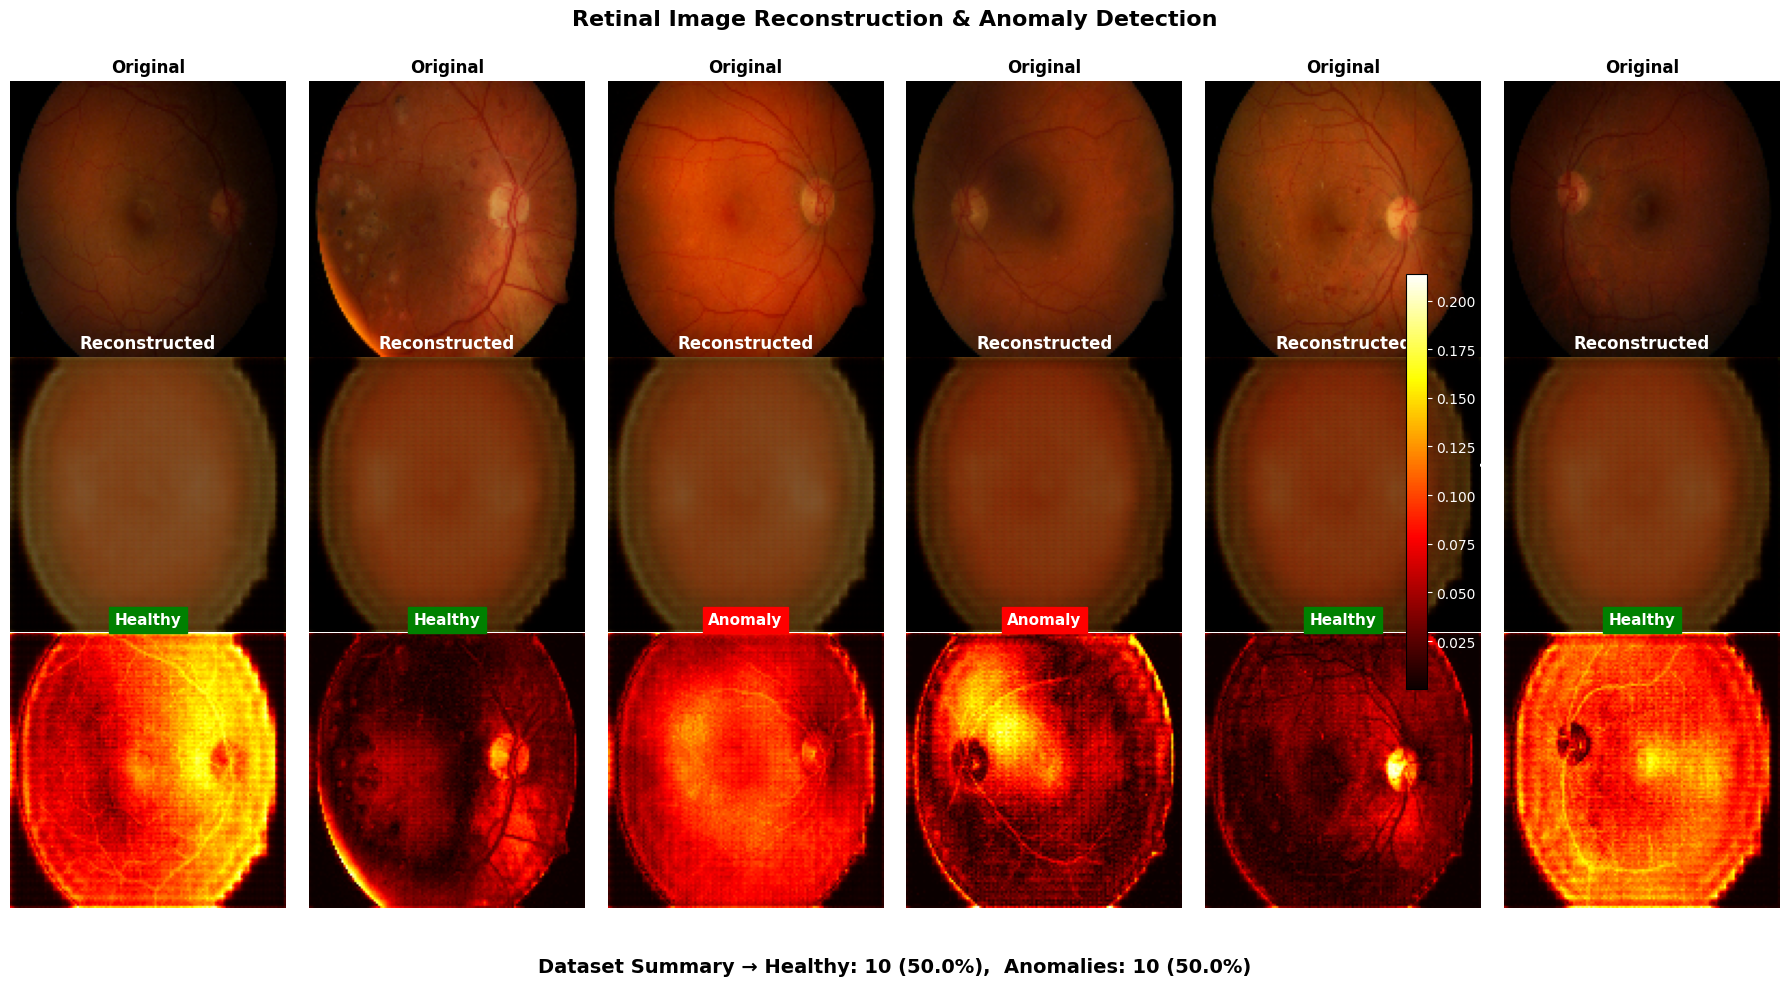

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_samples = 6
indices = np.random.choice(len(test_images), n_samples, replace=False)

threshold = np.median(errors)
pred_labels = (errors > threshold).astype(int)
n_healthy = np.sum(pred_labels == 0)
n_anomaly = np.sum(pred_labels == 1)
perc_healthy = (n_healthy / len(pred_labels)) * 100
perc_anomaly = (n_anomaly / len(pred_labels)) * 100

fig, axes = plt.subplots(3, n_samples, figsize=(3*n_samples, 9))

for col, i in enumerate(indices):
    orig = test_images[i]
    recon = reconstructed[i]
    error_map = np.abs(orig - recon).mean(axis=-1)
    label = "Healthy" if pred_labels[i] == 0 else "Anomaly"
    label_color = "green" if label == "Healthy" else "red"

    # Original
    axes[0, col].imshow(orig)
    axes[0, col].axis("off")
    axes[0, col].set_title("Original", fontsize=12, fontweight="bold")

    # Reconstructed
    axes[1, col].imshow(recon)
    axes[1, col].axis("off")
    axes[1, col].set_title("Reconstructed", fontsize=12, fontweight="bold", color="white")

    # Error Heatmap
    im = axes[2, col].imshow(error_map, cmap="hot")
    axes[2, col].axis("off")
    axes[2, col].set_title(
        f"{label}",
        fontsize=11, fontweight="bold", color="white",
        backgroundcolor=label_color, pad=6
    )

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
cbar.set_label("Reconstruction Error", fontsize=12, fontweight="bold",color="white")

cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.set_yticklabels([f"{tick:.3f}" for tick in cbar.get_ticks()], color='white')

# Dataset Summary
plt.figtext(0.5, -0.05,
            f"Dataset Summary → Healthy: {n_healthy} ({perc_healthy:.1f}%),  Anomalies: {n_anomaly} ({perc_anomaly:.1f}%)",
            wrap=True, horizontalalignment='center', fontsize=14, fontweight='bold')

plt.suptitle("Retinal Image Reconstruction & Anomaly Detection", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()


# **ANOMALY DETECTION AND DATASET STATISTICS**

Test images shape: (20, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
Reconstructed shape: (20, 128, 128, 3)
Reconstruction errors: [0.01416453 0.00911632 0.00857544 0.01183341 0.01529876 0.00915477
 0.00928878 0.00543292 0.00674248 0.0044945  0.01492821 0.00609032
 0.00974724 0.05227117 0.00634459 0.00512071 0.00726385 0.0205615
 0.00993625 0.02560984]


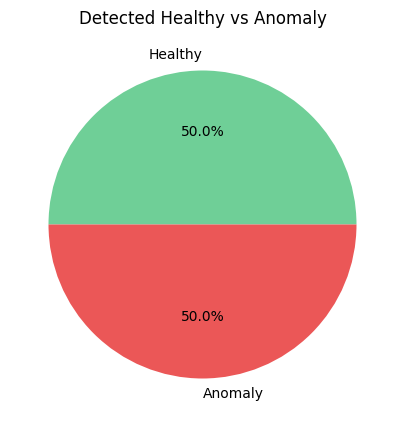

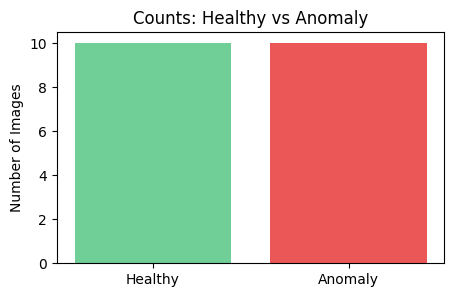

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Getting test images
test_images = train[:20]
print("Test images shape:", test_images.shape)  #(20, 128, 128, 3)

# Predict reconstructions
reconstructed_images = vae.predict(test_images)
print("Reconstructed shape:", reconstructed_images.shape)

errors = np.mean((test_images - reconstructed_images) ** 2, axis=(1,2,3))
print("Reconstruction errors:", errors)

threshold = np.median(errors)
predicted_labels = (errors > threshold).astype(int)

n_healthy = int(np.sum(predicted_labels == 0))
n_anomaly = int(np.sum(predicted_labels == 1))

plt.figure(figsize=(5,5))
plt.pie(
    [n_healthy, n_anomaly],
    labels=["Healthy", "Anomaly"],
    autopct="%1.1f%%",
    colors=["#6FCF97", "#EB5757"]
)
plt.title("Detected Healthy vs Anomaly")
plt.show()

plt.figure(figsize=(5,3))
plt.bar(
    ["Healthy","Anomaly"],
    [n_healthy, n_anomaly],
    color=["#6FCF97", "#EB5757"]
)
plt.title("Counts: Healthy vs Anomaly")
plt.ylabel("Number of Images")
plt.show()
